In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

GENERATED_DIR = Path.cwd() / "generated"

In [2]:
ACOUSTIC_DIR = GENERATED_DIR / "acoustic"
LINGUISTIC_DIR = GENERATED_DIR / "linguistic_frame"

In [3]:
DATA_SIZE = 5000

acoustic_paths = sorted(ACOUSTIC_DIR.glob("*"))[:DATA_SIZE] # Remove mean.npy and std.npy
linguistic_paths = sorted(LINGUISTIC_DIR.glob("*"))[:DATA_SIZE]
len(acoustic_paths), len(linguistic_paths)

(5000, 5000)

In [4]:
acoustic_arrays = [np.load(path) for path in acoustic_paths]
linguistic_arrays = [np.load(path) for path in linguistic_paths]

In [5]:
acoustic_arrays[0].dtype

dtype('float32')

In [6]:
# Truncate, same length
acoustic_arrays = [ac_arr[:len(ln_arr)] for ac_arr, ln_arr in zip(acoustic_arrays, linguistic_arrays)]

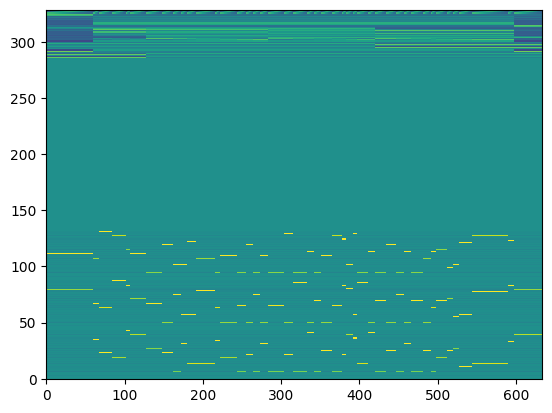

In [7]:
plt.imshow(linguistic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [8]:
linguistic_arrays[0].shape

(634, 329)

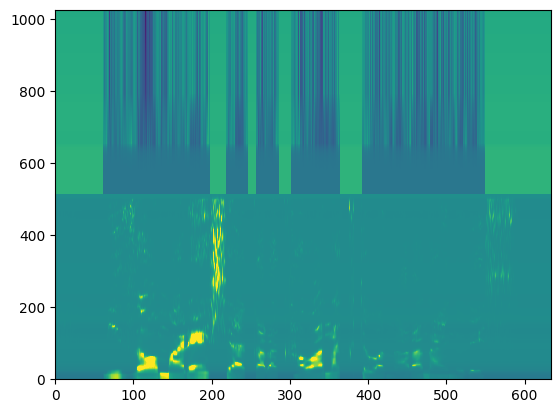

In [9]:
plt.imshow(acoustic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [10]:
# f0 0:1, sp 1:514, ap 514:1027

In [11]:
def _ds_gen(begin, end):
    for lng, aco in zip(linguistic_arrays[begin:end], acoustic_arrays[begin:end]):
        yield lng, aco
        
whole_tr_ds = tf.data.Dataset.from_generator(
    _ds_gen,
    args=(0, 4000),
    output_signature=(
        tf.TensorSpec(shape=(None, 329), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 1027), dtype=tf.float32),
    )
)

2022-10-16 06:47:18.546130: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-16 06:47:18.549703: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-16 06:47:18.549896: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:991] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-16 06:47:18.550526: I tensorflow/core/platform/cpu_feature_guard.cc:194] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE3 SSE4.1 SSE4.2 AVX
To enable them in other operations, rebuild TensorFlow with the appropriate 

In [19]:
def _convert_ds(ds):
    lng = ds.map(lambda x,y: x).flat_map(tf.data.Dataset.from_tensor_slices)
    f0 = ds.map(lambda x,y: y[:, 0:1]).flat_map(tf.data.Dataset.from_tensor_slices)
    sp = ds.map(lambda x,y: y[:, 1:514]).flat_map(tf.data.Dataset.from_tensor_slices)
    ap = ds.map(lambda x,y: y[:, 514:1027]).flat_map(tf.data.Dataset.from_tensor_slices)
    y = tf.data.Dataset.zip((f0, sp, ap))
    return tf.data.Dataset.zip((lng, y))

BATCH_SIZE = 2 ** 15

tr_ds = _convert_ds(whole_tr_ds).shuffle(BATCH_SIZE * 3).batch(BATCH_SIZE).prefetch(5)

In [13]:
from tensorflow.keras.layers import *

def _extend(ipt, name):
    
    resid_feature = Reshape((1, -1))(Dense(32, activation='relu', name=f'{name}_res_f')(ipt))
    resid_space = Reshape((-1, 1))(Dense(16, activation='relu', name=f'{name}_res_s')(ipt))
    
    x = Reshape((1, -1))(ipt)
    x = Conv1DTranspose(128, 7, strides=4, padding='same', name=f'{name}_c_1')(x)
    x = ReLU()(x)
    x = Conv1DTranspose(32, 7, strides=4, padding='same')(x)
    x = Add(name=f'{name}_add')([x, resid_feature, resid_space])
    x = ReLU()(x)
    x = Conv1DTranspose(8, 7, strides=4, padding='same')(x)
    x = ReLU()(x)
    x = Conv1DTranspose(2, 7, strides=4, padding='same')(x)
    x = ReLU()(x)
    x = Conv1DTranspose(1, 3, strides=2, padding='same')(x)
    x = Flatten()(x)
    last = Dense(1)(x)
    x = Concatenate(name=f'{name}_out')([x, last])
    return x


def get_model(input_dim = 329, f0_dim=1, sp_dim=513, ap_dim=513):
    ipt = tf.keras.layers.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(256,)(ipt)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dense(256,)(x)
    x = tf.keras.layers.ReLU()(x)
    
    sp_out = _extend(x, 'sp')
    ap_out = _extend(x, 'ap')
    
    x = tf.keras.layers.Dense(64,)(x)
    x = tf.keras.layers.ReLU()(x)

    f0_out = tf.keras.layers.Dense(1, name="f0")(x)

    model = tf.keras.models.Model(inputs=ipt, outputs=(f0_out, sp_out, ap_out))
    return model

model = get_model()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 329)]        0           []                               
                                                                                                  
 dense (Dense)                  (None, 256)          84480       ['input_1[0][0]']                
                                                                                                  
 re_lu (ReLU)                   (None, 256)          0           ['dense[0][0]']                  
                                                                                                  
 dense_1 (Dense)                (None, 256)          65792       ['re_lu[0][0]']                  
                                                                                              

 spose)                                                                                           
                                                                                                  
 dense_4 (Dense)                (None, 64)           16448       ['re_lu_1[0][0]']                
                                                                                                  
 flatten (Flatten)              (None, 512)          0           ['conv1d_transpose_3[0][0]']     
                                                                                                  
 flatten_1 (Flatten)            (None, 512)          0           ['conv1d_transpose_7[0][0]']     
                                                                                                  
 re_lu_10 (ReLU)                (None, 64)           0           ['dense_4[0][0]']                
                                                                                                  
 dense_2 (

In [17]:
from tensorflow.keras.losses import MeanSquaredError as MSE

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=(MSE(), MSE(), MSE()),
)

In [ ]:
model.fit(tr_ds, epochs=1000)

Epoch 1/1000
116/116 [==============================] - 48s 409ms/step - loss: 1.0425 - f0_loss: 0.1444 - sp_out_loss: 0.6637 - ap_out_loss: 0.2344
Epoch 2/1000
116/116 [==============================] - 48s 409ms/step - loss: 1.0390 - f0_loss: 0.1444 - sp_out_loss: 0.6608 - ap_out_loss: 0.2338
Epoch 3/1000
116/116 [==============================] - 48s 410ms/step - loss: 1.0364 - f0_loss: 0.1442 - sp_out_loss: 0.6587 - ap_out_loss: 0.2334
Epoch 4/1000
116/116 [==============================] - 48s 410ms/step - loss: 1.0325 - f0_loss: 0.1436 - sp_out_loss: 0.6561 - ap_out_loss: 0.2328
Epoch 5/1000
116/116 [==============================] - 49s 412ms/step - loss: 1.0302 - f0_loss: 0.1435 - sp_out_loss: 0.6542 - ap_out_loss: 0.2324
Epoch 6/1000
116/116 [==============================] - 49s 413ms/step - loss: 1.0271 - f0_loss: 0.1431 - sp_out_loss: 0.6522 - ap_out_loss: 0.2318
Epoch 7/1000
116/116 [==============================] - 48s 411ms/step - loss: 1.0245 - f0_loss: 0.1428 - sp_out

NameError: name 'acoustic_arrays' is not defined

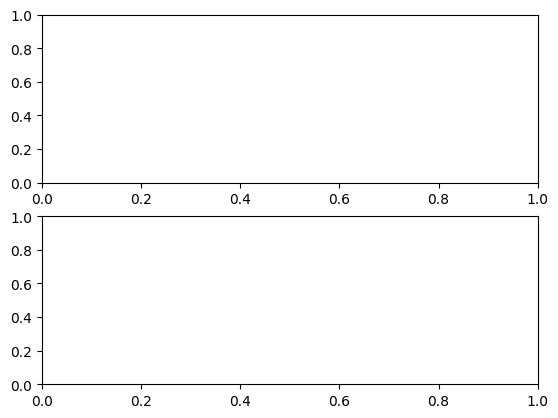

In [3]:
import librosa.display

idx = 4901

fig, ax = plt.subplots(2, 1)
ax[0].imshow(acoustic_arrays[idx][:, 1:514].T)
ax[1].imshow(model.predict(linguistic_arrays[idx])[1].T)

plt.tight_layout()

In [22]:
f0, sp, ap = model.predict(linguistic_arrays[idx])

29/29 [==============================] - 0s 3ms/step


In [23]:
mean = np.load("generated/acoustic/mean.npy")
std = np.load("generated/acoustic/std.npy")

def to_audio(f0, sp, ap):
    f0_mean, sp_mean, ap_mean = mean[0:1], mean[1:1+513], mean[1+513:]
    f0_std, sp_std, ap_std = std[0:1], std[1:1+513], std[1+513:]
    f0 = f0_mean + f0_std * f0
    sp = sp_mean + sp_std * sp
    ap = ap_mean + ap_std * ap
    audio = pw.synthesize(f0[:, 0].astype("double"), sp.astype("double"), ap.astype("double"), 22050)
    return audio

In [24]:
import pyworld as pw
import IPython

audio = to_audio(f0, sp, ap)
IPython.display.Audio(audio, rate=22050)

In [27]:
import pyworld as pw
import IPython

audio = to_audio(f0_arrays[idx], sp_arrays[idx], ap_arrays[idx])
IPython.display.Audio(audio, rate=22050)

NameError: name 'f0_arrays' is not defined